In [67]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
stocks = [
    "TMPV.NS",
    "M&M.NS",
    "MARUTI.NS",
    "BAJAJ-AUTO.NS"
]

In [71]:
startDate = "2010-01-01"
endDate = "2026-07-01"

In [73]:
df = yf.download(
    stocks,
    start=startDate,
    end=endDate,
    auto_adjust="FALSE"
)

[*********************100%***********************]  4 of 4 completed


In [77]:
print(df.head())

Price              Close                                               High  \
Ticker     BAJAJ-AUTO.NS      M&M.NS    MARUTI.NS     TMPV.NS BAJAJ-AUTO.NS   
Date                                                                          
2010-01-04    570.148315  234.559341  1369.438843  149.194641    583.611558   
2010-01-05    572.781921  238.877380  1338.015503  146.595093    578.410815   
2010-01-06    563.926941  244.607269  1290.173706  146.820740    576.057048   
2010-01-07    554.035339  239.946579  1282.803589  141.802139    569.144505   
2010-01-08    544.867920  239.967285  1265.017334  142.578415    559.549144   

Price                                                     Low              \
Ticker          M&M.NS    MARUTI.NS     TMPV.NS BAJAJ-AUTO.NS      M&M.NS   
Date                                                                        
2010-01-04  236.251304  1400.553426  149.654970    567.844087  225.352189   
2010-01-05  244.140089  1383.650296  152.489230    562.8901

In [79]:
adj_close_prices = df["Close"]
adj_close_prices.head()

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,TMPV.NS
Date,,,,
2010-01-04,570.148315,234.559341,1369.438843,149.194641
2010-01-05,572.781921,238.877380,1338.015503,146.595093
2010-01-06,563.926941,244.607269,1290.173706,146.820740
2010-01-07,554.035339,239.946579,1282.803589,141.802139
2010-01-08,544.867920,239.967285,1265.017334,142.578415


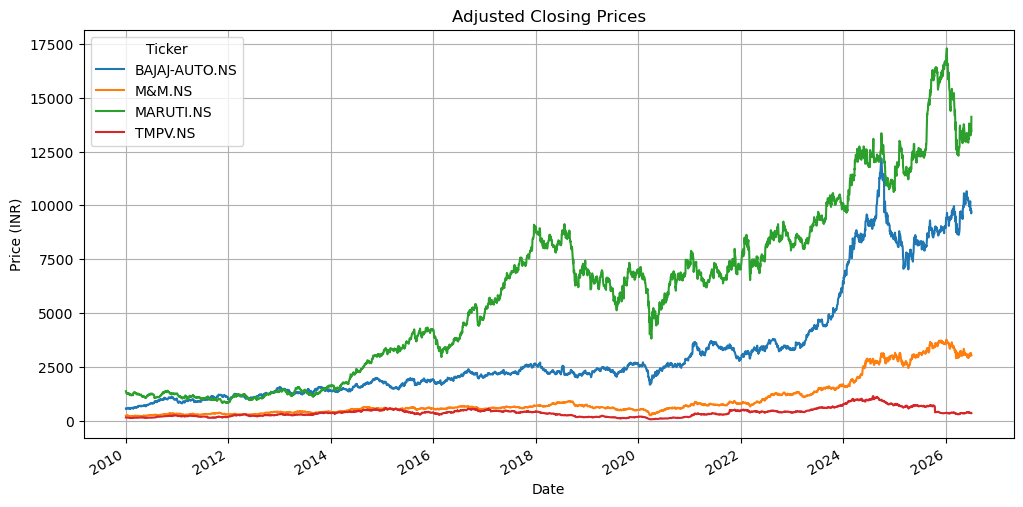

In [81]:
adj_close_prices.plot(figsize=(12,6))

plt.title("Adjusted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid("True")

plt.show()

In [83]:
daily_returns = adj_close_prices.pct_change()

daily_returns.head()

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,TMPV.NS
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.004619,0.018409,-0.022946,-0.017424
2010-01-06,-0.015460,0.023987,-0.035756,0.001539
2010-01-07,-0.017541,-0.019054,-0.005712,-0.034182
2010-01-08,-0.016547,0.000086,-0.013865,0.005474


In [85]:
daily_returns.describe()

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,TMPV.NS
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,0.000827,0.000808,0.000726,0.000551
std,0.016125,0.018936,0.017506,0.025848
min,-0.136801,-0.092956,-0.169092,-0.401513
25%,-0.007954,-0.010028,-0.008368,-0.012308
50%,0.000273,0.000555,0.000000,0.000000
75%,0.008986,0.010996,0.009392,0.013138
max,0.121106,0.168505,0.135149,0.204467


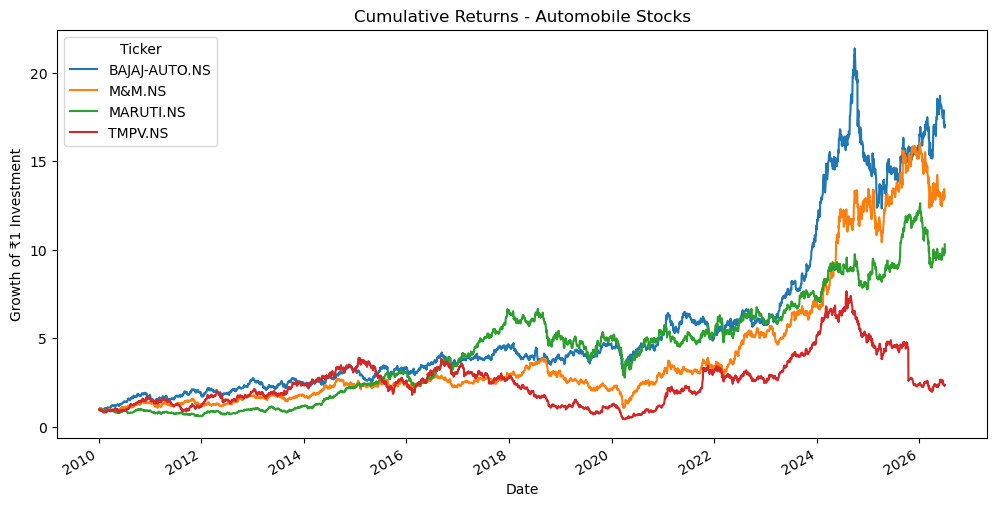

In [87]:
cumulative_returns = (1 + daily_returns).cumprod()

cumulative_returns.plot(figsize=(12,6))

plt.title("Cumulative Returns - Automobile Stocks")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Investment")
plt.show()

In [89]:
annual_volatility = daily_returns.std() * np.sqrt(252)

annual_volatility

Ticker
BAJAJ-AUTO.NS    0.255980
M&M.NS           0.300603
MARUTI.NS        0.277899
TMPV.NS          0.410326
dtype: float64

In [91]:
performance = pd.DataFrame()

performance["Average Daily Return"] = daily_returns.mean()

performance["Annual Return"] = daily_returns.mean() * 252

performance["Annual Volatility"] = daily_returns.std() * np.sqrt(252)

performance

,Average Daily Return,Annual Return,Annual Volatility
Ticker,,,
BAJAJ-AUTO.NS,0.000827,0.208353,0.255980
M&M.NS,0.000808,0.203586,0.300603
MARUTI.NS,0.000726,0.183013,0.277899
TMPV.NS,0.000551,0.138880,0.410326


In [93]:
risk_free_rate = 0.06

sharpe_ratio = (
    (daily_returns.mean()*252 - risk_free_rate)
    /
    (daily_returns.std()*np.sqrt(252))
)

sharpe_ratio

Ticker
BAJAJ-AUTO.NS    0.579549
M&M.NS           0.477660
MARUTI.NS        0.442652
TMPV.NS          0.192236
dtype: float64

In [95]:
correlation = daily_returns.corr()

correlation

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,TMPV.NS
Ticker,,,,
BAJAJ-AUTO.NS,1.000000,0.392987,0.403757,0.340784
M&M.NS,0.392987,1.000000,0.445290,0.423761
MARUTI.NS,0.403757,0.445290,1.000000,0.387228
TMPV.NS,0.340784,0.423761,0.387228,1.000000


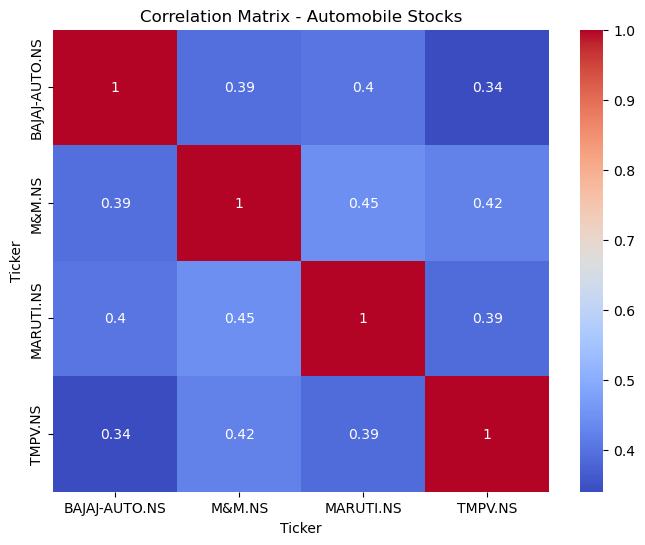

In [98]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Automobile Stocks")

plt.show()

In [106]:
monthly_returns = adj_close_prices.resample("ME").last().pct_change()

monthly_returns.head()

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,TMPV.NS
Date,,,,
2010-01-31,NaN,NaN,NaN,NaN
2010-02-28,0.040024,-0.009631,0.050739,0.024267
2010-03-31,0.108464,0.074373,-0.028768,0.065382
2010-04-30,0.038986,-0.028078,-0.097500,0.151643
2010-05-31,0.055414,0.088473,-0.033485,-0.134770


In [108]:
rolling_max = adj_close_prices.cummax()

drawdown = (adj_close_prices - rolling_max) / rolling_max

max_drawdown = drawdown.min()

max_drawdown

Ticker
BAJAJ-AUTO.NS   -0.423135
M&M.NS          -0.722771
MARUTI.NS       -0.582647
TMPV.NS         -0.890783
dtype: float64

In [110]:
final_summary = pd.DataFrame({
    "Annual Return": daily_returns.mean()*252,
    "Annual Volatility": daily_returns.std()*np.sqrt(252),
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown": max_drawdown
})

final_summary

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Ticker,,,,
BAJAJ-AUTO.NS,0.208353,0.255980,0.579549,-0.423135
M&M.NS,0.203586,0.300603,0.477660,-0.722771
MARUTI.NS,0.183013,0.277899,0.442652,-0.582647
TMPV.NS,0.138880,0.410326,0.192236,-0.890783
